In [1]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import vectorbt as vbt
import talib

# 1. XAG

## 1.1 Data Cleaning

In [2]:
xag = pd.read_csv('data/COMMODITY/XAG_USD.csv', index_col=0)

print("raw data shape:", xag.shape)
print('\ncolumn names:', xag.columns.tolist())
print("\ndata types:\n", xag.dtypes)
print("\nfirt 5 rows:\n", xag.head())

raw data shape: (379053, 14)

column names: ['symbol', 'time', 'file_time', 'status', 'open_bid', 'high_bid', 'low_bid', 'close_bid', 'open_ask', 'high_ask', 'low_ask', 'close_ask', 'tick_cnt', 'time_frame']

data types:
 symbol         object
time           object
file_time       int64
status         object
open_bid      float64
high_bid      float64
low_bid       float64
close_bid     float64
open_ask      float64
high_ask      float64
low_ask       float64
close_ask     float64
tick_cnt        int64
time_frame     object
dtype: object

firt 5 rows:
     symbol                       time     file_time status  open_bid  \
0  XAG_USD  2025-01-01 23:04:00+00:00  202501012304    NaN   28.9575   
1  XAG_USD  2025-01-01 23:05:00+00:00  202501012305    NaN   28.9545   
2  XAG_USD  2025-01-01 23:06:00+00:00  202501012306    NaN   28.9620   
3  XAG_USD  2025-01-01 23:07:00+00:00  202501012307    NaN   28.9670   
4  XAG_USD  2025-01-01 23:08:00+00:00  202501012308    NaN   28.9670   

   high_

In [3]:
## Set `time` as the index
xag['time'] = pd.to_datetime(xag['time'])
xag.set_index('time', inplace=True)
print(f'[1] Set `time` as index')

## Drop rows with missing `status`
mask_valid = xag['status'].notna()
before = len(xag)
xag = xag[mask_valid].copy()
print(f'[2] Dropped rows with missing `status`: {before - len(xag)}')

## Drop unnecessary columns
xag = xag.drop(columns=['symbol', 'file_time', 'status', 'time_frame'])
print(f'[3] Dropped columns: symbol, file_time, status, time_frame')

## Define mid price for open, high, low, and close
xag['open'] = (xag['open_bid'] + xag['open_ask']) / 2  # Open
xag['high'] = (xag['high_bid'] + xag['high_ask']) / 2  # High
xag['low'] = (xag['low_bid'] + xag['low_ask']) / 2  # Low
xag['close'] = (xag['close_bid'] + xag['close_ask']) / 2  # Close
print(f'[4] Defined mid prices for: open, high, low, close')

print(f'\nData shape after preprocessing: {xag.shape}')
print(f'Time range: {xag.index.min().date()} ~ {xag.index.max().date()}')
print(f'Total trading days: {xag.index.normalize().nunique()}')

[1] Set `time` as index
[2] Dropped rows with missing `status`: 19253
[3] Dropped columns: symbol, file_time, status, time_frame
[4] Defined mid prices for: open, high, low, close

Data shape after preprocessing: (359800, 13)
Time range: 2025-01-21 ~ 2026-01-30
Total trading days: 320


=== Key features descriptive statistics ===
              open         high          low        close    tick_cnt
count  359800.0000  359800.0000  359800.0000  359800.0000  359800.000
mean       44.5996      44.6179      44.5810      44.5998      79.983
std        17.2123      17.2323      17.1914      17.2125      96.976
min        28.4365      28.4505      28.3445      28.4360       1.000
25%        33.0435      33.0515      33.0355      33.0439      28.000
50%        37.9075      37.9135      37.9008      37.9079      53.000
75%        49.0442      49.0632      49.0247      49.0451     100.000
max       121.6261     121.6736     121.5357     121.6059    1114.000


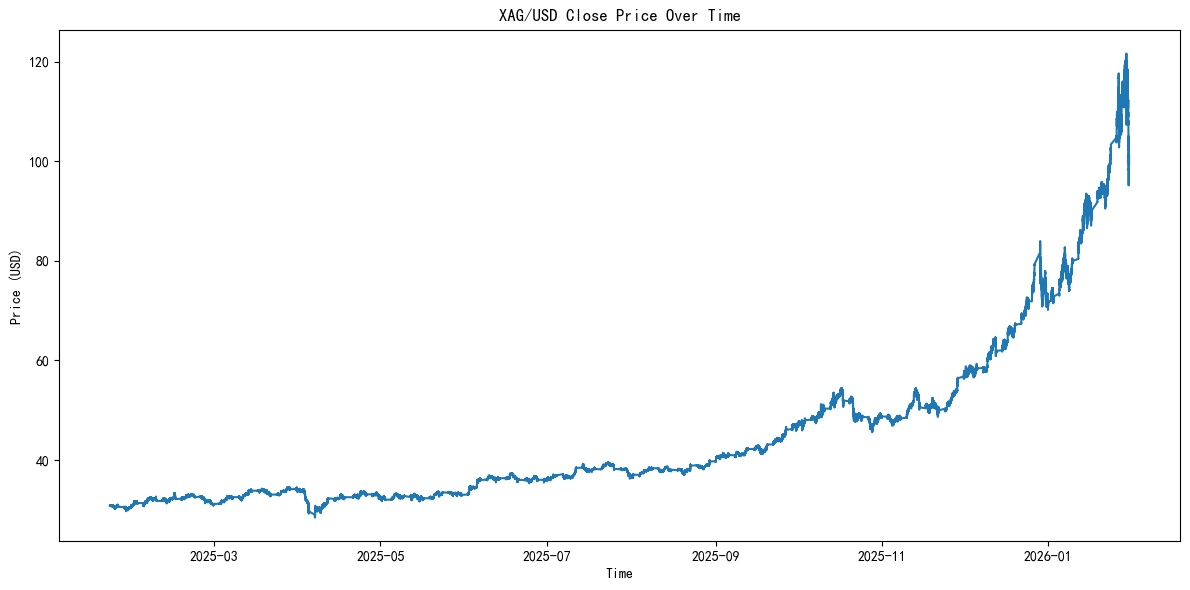

Data cleaning and EDA completed. Ready for feature engineering.


In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

key_cols = ['open', 'high', 'low', 'close', 'tick_cnt']
print("=== Key features descriptive statistics ===")
print(xag[key_cols].describe().round(4))

## plot close price over time
plt.figure(figsize=(12, 6))
plt.plot(xag.index, xag['close'])
plt.title('XAG/USD Close Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()
print('Data cleaning and EDA completed. Ready for feature engineering.')

## 1.2 Feature Engineering (HFT factors)

### 1.2.1 Bid-Ask Spread & Order Book Pressure

In [5]:
# define rolling window size
n=10

In [6]:
# F01: Quoted Bid-Ask Spread
xag['QS']=xag['close_ask'] - xag['close_bid']
# The fundamental measure of market liquidity. A widening spread signals deteriorating liquidity and foreshadows short-term volatility increases; 
# a tightening spread is consistent with trending price action

# F02: Relative Bid-Ask Spread
xag['RS'] = (xag['close_ask'] - xag['close_bid']) / xag['close']
# Price-normalized spread enabling cross-sectional comparison. Negatively correlated with short-horizon returns; 
# widely used as a proxy for the liquidity risk premium.

# F03: Spread Change Z-Score
xag['SCZ'] = (xag['QS'] - xag['QS'].rolling(window=n).mean()) / xag['QS'].rolling(window=n).std()
# Captures sudden liquidity shocks. An abnormally wide spread often precedes large-order market impact; 
# used as a position-sizing or stop-loss trigger in execution models

# F04: Intrabar Spread Asymmetry
xag['ISA'] = (xag['high_ask'] - xag['high_bid']) - (xag['low_ask'] - xag['low_bid'])
# Measures within-bar spread imbalance between bid and ask sides. Positive values (ask-side expansion at highs) signal market stress; 
# negative values imply bid-side support.

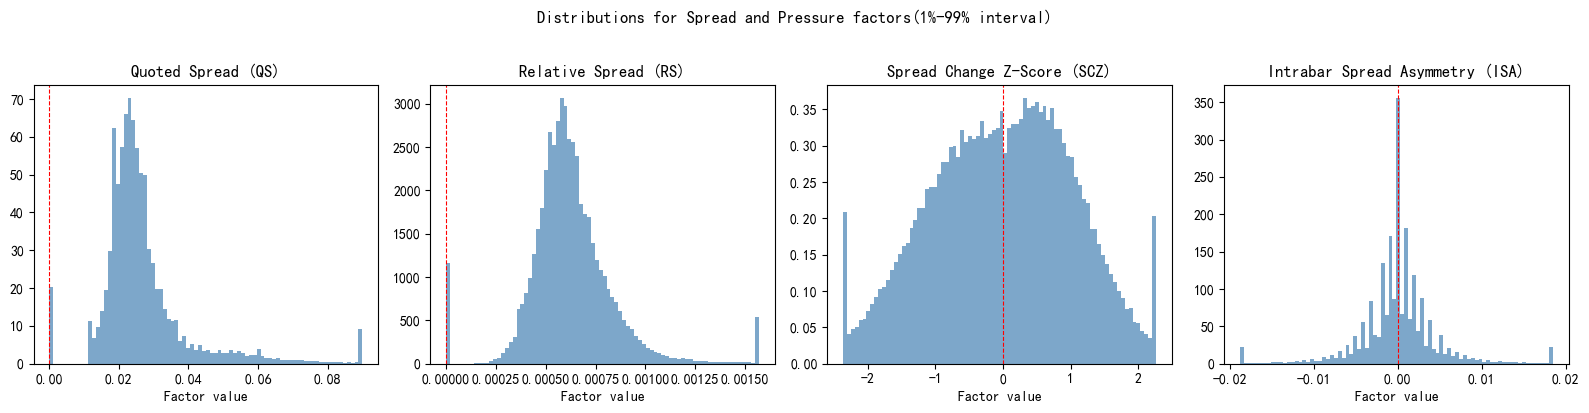

In [7]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['QS', 'RS', 'SCZ', 'ISA']
titles = ['Quoted Spread (QS)', 'Relative Spread (RS)', 'Spread Change Z-Score (SCZ)', 'Intrabar Spread Asymmetry (ISA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Spread and Pressure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.2 Price Momentum & Mean Reversion

In [8]:
#F05: Mid-Price Log Return
xag['MPR'] = np.log(xag['close'])-np.log(xag['close'].shift(n))
# Log return of the mid-price, eliminating single-sided quote noise. Short lookbacks (5–15 min) tend to mean-revert; 
# longer lookbacks (30–60 min) exhibit momentum persistence.

#F06: Intrabar Price Skewness
xag['IPS'] = (xag['close']-xag['open'])/(xag['high']-xag['low'])
# Analogous to Williams %R. Close near the bar's high (+1) signals bullish dominance; 
# near the low (−1) signals bearish dominance. Predictive of the next bar's direction.

#F07: Open-to-Close Gap
xag['OCG'] = (xag['open'] - xag['close'].shift(1)) / xag['close'].shift(1)
# Inter-bar mid-price gap between successive minutes. At high frequencies, gaps exhibit strong mean-reversion tendencies, 
# forming the basis of scalping and gap-fade strategies.

#F08: Range Expansion Ratio
xag['range'] = xag['high'] - xag['low']
xag['RER'] = xag['range'] / xag['range'].rolling(window=n).mean()
# RER > 1.5 often accompanies trend breakouts; RER < 0.5 indicates price compression (low-volatility regime), 
# frequently preceding explosive directional moves.

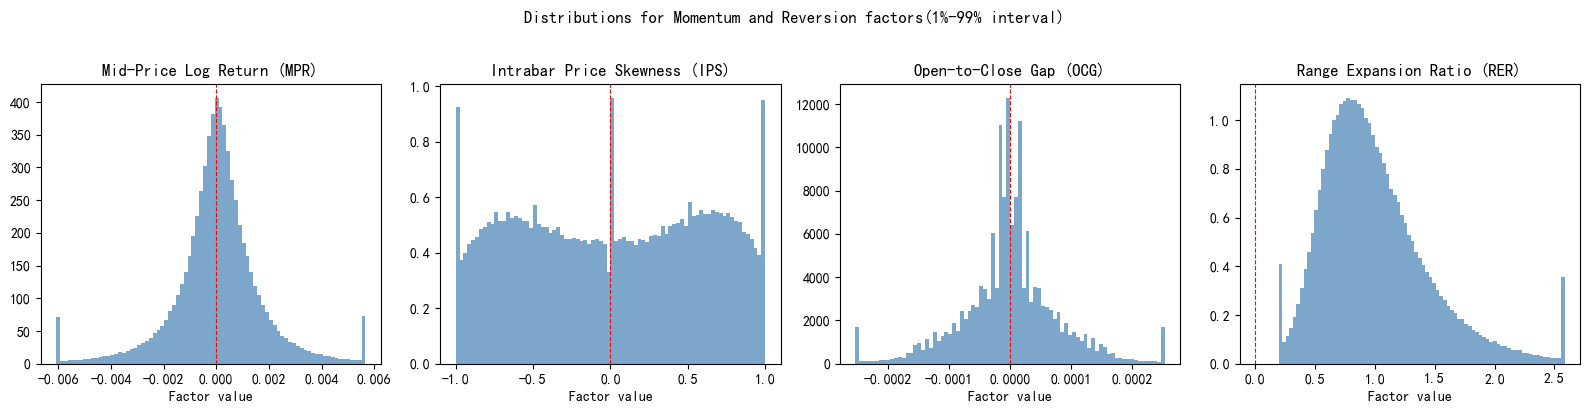

In [9]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['MPR', 'IPS', 'OCG', 'RER']
titles = ['Mid-Price Log Return (MPR)', 'Intrabar Price Skewness (IPS)', 'Open-to-Close Gap (OCG)', 'Range Expansion Ratio (RER)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Momentum and Reversion factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.3 Volume Proxy & Trading Activity

In [10]:
#F09: Tick Density Ratio
xag['TDR'] = xag['tick_cnt'] / xag['tick_cnt'].rolling(window=n).mean()
# Normalizes current tick activity against its rolling average. TDR significantly above 1 indicates unusual order flow 
# — strongly associated with institutional activity and trend initiation.

#F10: Price-Tick Correlation
xag['delta']=xag['close'].diff()
xag['PTC'] = xag['delta'].rolling(window=n).corr(xag['tick_cnt'])
# Rolling correlation between mid-price changes and tick counts. Positive correlation confirms volume-price agreement (trend valid); 
# negative divergence signals potential reversal.

#F11: Tick-Weighted Mid Deviation
xag['amount'] = xag['tick_cnt'] * xag['close']
xag['TWAP'] = xag['amount'].rolling(window=n).sum() / xag['tick_cnt'].rolling(window=n).sum()
xag['TWMD'] = xag['close'] - xag['TWAP']
# VWAP analog using tick counts as volume proxy. Deviation from tick-weighted average is a mean-reversion signal; 
# persistent one-sided deviation indicates informed order flow.

#F12: Tick Acceleration
xag['TACC_R'] = (xag['tick_cnt'] - xag['tick_cnt'].shift(1))/xag['tick_cnt'].shift(1)
# First difference of tick counts — an activity acceleration indicator. Sustained tick acceleration is a hallmark of 
# algorithmic order slicing (TWAP/VWAP execution), predicting short-term price continuation.

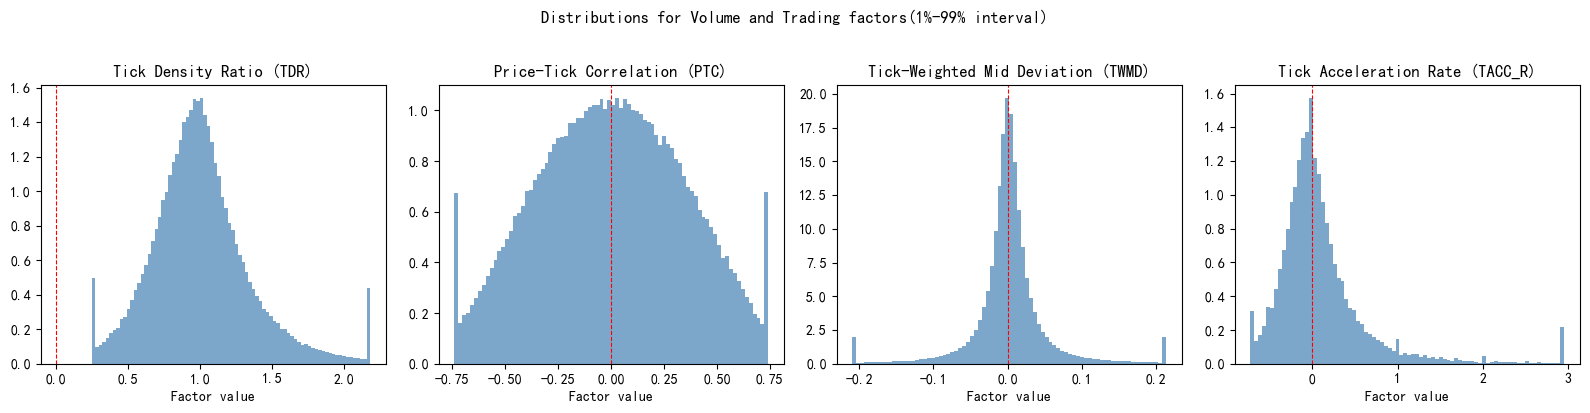

In [11]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['TDR', 'PTC', 'TWMD', 'TACC_R']
titles = ['Tick Density Ratio (TDR)', 'Price-Tick Correlation (PTC)', 'Tick-Weighted Mid Deviation (TWMD)', 'Tick Acceleration Rate (TACC_R)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volume and Trading factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.4 Volatility & Risk Factors

In [12]:
## F13:Parkinson Volatility
xag['Parkinson']=np.log(xag['high']/xag['low'])**2
xag['PV'] = np.sqrt(xag['Parkinson'].rolling(window=n).mean()/(4*np.log(2)))
# Efficient range-based volatility estimator utilizing high and low prices. Reduces estimator variance by 
# ~5× versus close-to-close estimators — essential for noisy minute-level data.

# F14: Garman-Klass Volatility
xag['GKV'] = 0.5 * np.log((xag['high']/xag['low'])**2) - (2*np.log(2)-1) * np.log((xag['close']/xag['open'])**2)
# Optimal unbiased estimator exploiting all four OHLC prices. Compute independently on bid and ask series and average. 
# Outperforms Parkinson by further incorporating open-close information.

#F15: Volatility Regime Ratio
short = 5
long = 60
xag['VRR'] = xag['PV'].rolling(window=short).mean() / xag['PV'].rolling(window=long).mean()
# Short-to-long realized volatility ratio. VRR > 1 flags abnormal near-term turbulence (risk-off signal); 
# rising VRR trend often precedes large directional breaks. Central to regime detection.

#F16: Bid-Ask Volatility Asymmetry
xag['BVA'] = xag['close_bid'].rolling(window=n).std() / xag['close_ask'].rolling(window=n).std()
# Volatility differential between bid and ask quote series. Positive BVA (bid more volatile) implies elevated buy-side pressure; 
# negative implies sell-side dominance. Reflects structural order book imbalance.

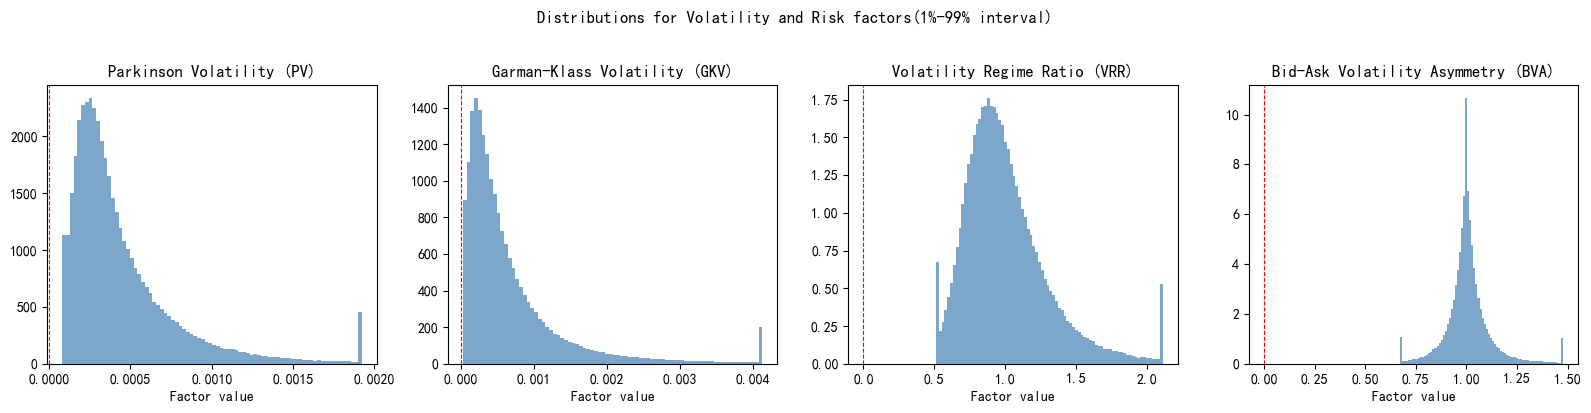

In [13]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['PV', 'GKV', 'VRR', 'BVA']
titles = ['Parkinson Volatility (PV)', 'Garman-Klass Volatility (GKV)', 'Volatility Regime Ratio (VRR)', 'Bid-Ask Volatility Asymmetry (BVA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volatility and Risk factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.5 Market Microstructure & Information Flow

In [14]:
#F17: Effective Spread Proxy
xag['ES']= 2*abs(xag['close']-xag['open'])
# Intrabar proxy for the effective spread — the actual transaction cost realized by traders. 
# When ES ≪ Quoted Spread, market efficiency is high. Divergence signals adverse selection and information asymmetry.

#F18: Roll Implied Spread
xag['delta_lag1']=xag['delta'].shift(1)
xag['cov'] = xag['delta'].rolling(window=n).cov(xag['delta_lag1'])
xag['RIS']= 2 * np.sqrt(np.maximum(-xag['cov'], 0))
# Classic Roll (1984) estimator that recovers the implicit spread from the serial covariance of mid-price changes. 
# Negative covariance is the microstructure fingerprint of the bid-ask bounce.

#F19: Kyle's Lambda (Price Impact)
xag['OF'] = np.sign(xag['delta']) * xag['tick_cnt']
cov_xy = xag['delta'].rolling(window=n).cov(xag['OF'])
var_x = xag['OF'].rolling(window=n).var()
xag['KL'] = cov_xy / var_x
# Kyle (1985) price impact coefficient estimated with tick counts as an order flow proxy. 
# λ̂ measures per-unit flow impact on price — a direct gauge of information asymmetry and market depth.

#F20: Amihud Illiquidity Ratio
xag['ILLIQ'] = abs(xag['delta']) / xag['tick_cnt']
xag['AIR'] = xag['ILLIQ'].rolling(window=n).mean()
# Amihud (2002) illiquidity ratio adapted to minute bars, with tick count replacing dollar volume. 
# Higher AIR means greater price impact per unit of order flow — illiquidity risk premium proxy.

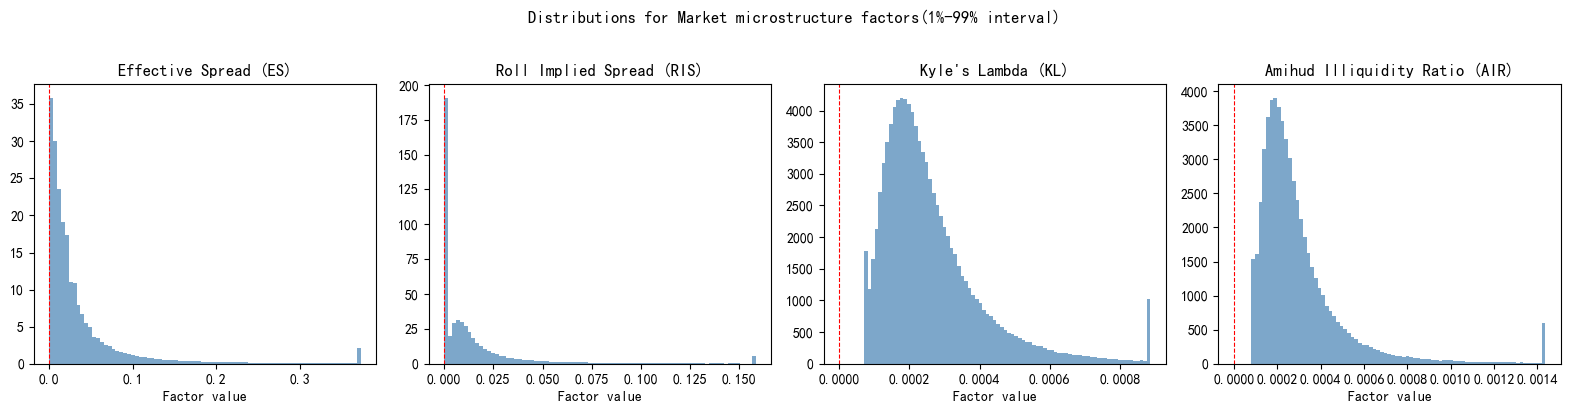

In [15]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['ES', 'RIS', 'KL', 'AIR']
titles = ['Effective Spread (ES)', 'Roll Implied Spread (RIS)', "Kyle's Lambda (KL)", 'Amihud Illiquidity Ratio (AIR)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Market microstructure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

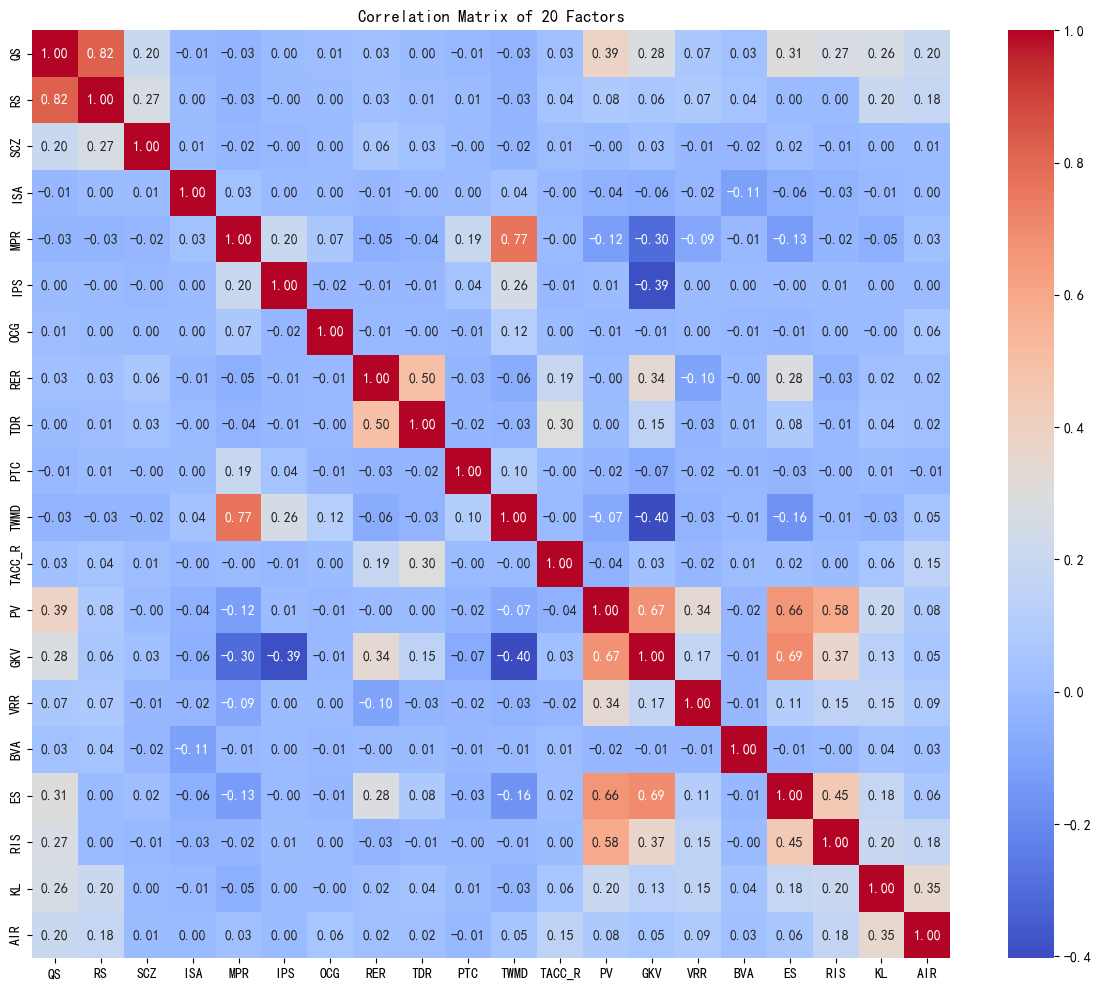

In [16]:
# factor correlation heatmap
plt.figure(figsize=(12, 10))
ALL_FACTORS = ['QS', 'RS', 'SCZ', 'ISA', 'MPR', 'IPS', 'OCG', 'RER', 'TDR', 'PTC', 'TWMD', 'TACC_R', 'PV', 'GKV', 'VRR', 'BVA', 'ES', 'RIS', 'KL', 'AIR']
corr_matrix = xag[ALL_FACTORS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of 20 Factors')
plt.tight_layout()
plt.show()


## 1.3 Factor testing

In [17]:
# Calculate forward returns for 5min, 10min, 20min, and 50min
xag['ret_5m'] = (xag['close'].shift(-5) - xag['close']) / xag['close']
xag['ret_10m'] = (xag['close'].shift(-10) - xag['close']) / xag['close']
xag['ret_20m'] = (xag['close'].shift(-20) - xag['close']) / xag['close']
xag['ret_50m'] = (xag['close'].shift(-50) - xag['close']) / xag['close']

## Classify returns into 2 classes: 0 for negative, 1 for positive
xag['trend_5m'] = (xag['ret_5m'] > 0).astype(int)
xag['trend_10m'] = (xag['ret_10m'] > 0).astype(int)
xag['trend_20m'] = (xag['ret_20m'] > 0).astype(int)
xag['trend_50m'] = (xag['ret_50m'] > 0).astype(int)

## Drop rows with NaN values
xag = xag.dropna()
print("Forward return calculation completed")
print(xag[['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']].describe().round(4))
print('Forward trend classification completed')
print(xag[['trend_5m', 'trend_10m', 'trend_20m', 'trend_50m']].sum())

Forward return calculation completed
            ret_5m      ret_10m      ret_20m      ret_50m
count  350054.0000  350054.0000  350054.0000  350054.0000
mean        0.0000       0.0000       0.0001       0.0002
std         0.0014       0.0021       0.0029       0.0046
min        -0.0549      -0.0632      -0.0834      -0.1103
25%        -0.0005      -0.0007      -0.0009      -0.0014
50%         0.0000       0.0001       0.0001       0.0002
75%         0.0006       0.0008       0.0012       0.0019
max         0.0394       0.0438       0.0590       0.0644
Forward trend classification completed
trend_5m     180184
trend_10m    182618
trend_20m    185277
trend_50m    190095
dtype: int64


In [18]:
# ──────────────────────────────────────────────────────────────────
# IC testing：every n-minute period Pearson IC 和 Rank IC
# ──────────────────────────────────────────────────────────────────
RET_HORIZONS = ['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']

def compute_ic_series(df, factor_col, ret_col, n):
    """every n-minute period compute Pearson IC and Rank IC(Spearman)"""
    ic_list = []
    for i in range(0, len(df) - n, n):
        factor_values = df[factor_col].iloc[i:i+n]
        returns = df[ret_col].iloc[i:i+n]
        if len(factor_values) > 1 and len(returns) > 1:
            pearson_ic = factor_values.corr(returns)
            rank_ic, _ = spearmanr(factor_values, returns)
            ic_list.append({'time': df.index[i], 'IC': pearson_ic, 'RankIC': rank_ic})
    return pd.DataFrame(ic_list).set_index("time")
    
period = 500

# Compute all factors'IC to 5-minute future return
print("=== IC testing result summary (ret_5m) ===\n")
for fac in ALL_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_5m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_5m) ===

QS                   | IC=+0.0079  IC_IR=+0.093  RankIC=+0.0075  RankIR=+0.095  Positive IC percentage=54.1%
RS                   | IC=+0.0110  IC_IR=+0.129  RankIC=+0.0169  RankIR=+0.213  Positive IC percentage=55.1%
SCZ                  | IC=+0.0009  IC_IR=+0.015  RankIC=+0.0009  RankIR=+0.014  Positive IC percentage=47.9%
ISA                  | IC=+0.0035  IC_IR=+0.061  RankIC=+0.0045  RankIR=+0.086  Positive IC percentage=51.1%
MPR                  | IC=-0.0427  IC_IR=-0.366  RankIC=-0.0472  RankIR=-0.496  Positive IC percentage=32.4%
IPS                  | IC=-0.0088  IC_IR=-0.179  RankIC=-0.0185  RankIR=-0.380  Positive IC percentage=40.1%
OCG                  | IC=-0.0048  IC_IR=-0.091  RankIC=-0.0052  RankIR=-0.112  Positive IC percentage=48.0%
RER                  | IC=+0.0047  IC_IR=+0.081  RankIC=+0.0046  RankIR=+0.088  Positive IC percentage=54.3%
TDR                  | IC=+0.0061  IC_IR=+0.092  RankIC=+0.0063  RankIR=+0.102  Posi

In [19]:
# Compute all factors'IC to 10-minute future return
print("=== IC testing result summary (ret_10m) ===\n")
for fac in ALL_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_10m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_10m) ===

QS                   | IC=+0.0098  IC_IR=+0.095  RankIC=+0.0093  RankIR=+0.095  Positive IC percentage=53.1%
RS                   | IC=+0.0141  IC_IR=+0.136  RankIC=+0.0217  RankIR=+0.220  Positive IC percentage=54.4%
SCZ                  | IC=+0.0037  IC_IR=+0.059  RankIC=+0.0029  RankIR=+0.047  Positive IC percentage=48.7%
ISA                  | IC=+0.0040  IC_IR=+0.062  RankIC=+0.0047  RankIR=+0.079  Positive IC percentage=50.4%
MPR                  | IC=-0.0552  IC_IR=-0.395  RankIC=-0.0578  RankIR=-0.493  Positive IC percentage=31.7%
IPS                  | IC=-0.0123  IC_IR=-0.254  RankIC=-0.0208  RankIR=-0.446  Positive IC percentage=38.7%
OCG                  | IC=-0.0079  IC_IR=-0.144  RankIC=-0.0085  RankIR=-0.171  Positive IC percentage=45.7%
RER                  | IC=+0.0045  IC_IR=+0.081  RankIC=+0.0033  RankIR=+0.066  Positive IC percentage=54.0%
TDR                  | IC=+0.0028  IC_IR=+0.042  RankIC=+0.0023  RankIR=+0.037  Pos

In [20]:
# Compute all factors'IC to 20-minute future return
print("=== IC testing result summary (ret_20m) ===\n")
for fac in ALL_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_20m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_20m) ===

QS                   | IC=+0.0075  IC_IR=+0.058  RankIC=+0.0075  RankIR=+0.060  Positive IC percentage=51.4%
RS                   | IC=+0.0134  IC_IR=+0.103  RankIC=+0.0236  RankIR=+0.188  Positive IC percentage=53.9%
SCZ                  | IC=+0.0030  IC_IR=+0.055  RankIC=+0.0013  RankIR=+0.022  Positive IC percentage=51.7%
ISA                  | IC=+0.0032  IC_IR=+0.044  RankIC=+0.0051  RankIR=+0.073  Positive IC percentage=49.1%
MPR                  | IC=-0.0716  IC_IR=-0.490  RankIC=-0.0719  RankIR=-0.570  Positive IC percentage=31.0%
IPS                  | IC=-0.0181  IC_IR=-0.371  RankIC=-0.0253  RankIR=-0.527  Positive IC percentage=33.7%
OCG                  | IC=-0.0086  IC_IR=-0.159  RankIC=-0.0097  RankIR=-0.191  Positive IC percentage=42.6%
RER                  | IC=+0.0040  IC_IR=+0.085  RankIC=+0.0038  RankIR=+0.091  Positive IC percentage=52.0%
TDR                  | IC=+0.0013  IC_IR=+0.021  RankIC=+0.0023  RankIR=+0.043  Pos

In [21]:
# Compute all factors'IC to 50-minute future return
print("=== IC testing result summary (ret_50m) ===\n")
for fac in ALL_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_50m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_50m) ===

QS                   | IC=+0.0070  IC_IR=+0.043  RankIC=+0.0096  RankIR=+0.059  Positive IC percentage=53.0%
RS                   | IC=+0.0156  IC_IR=+0.096  RankIC=+0.0313  RankIR=+0.190  Positive IC percentage=54.7%
SCZ                  | IC=+0.0040  IC_IR=+0.088  RankIC=+0.0049  RankIR=+0.102  Positive IC percentage=52.0%
ISA                  | IC=+0.0022  IC_IR=+0.026  RankIC=+0.0050  RankIR=+0.060  Positive IC percentage=50.4%
MPR                  | IC=-0.0931  IC_IR=-0.673  RankIC=-0.0872  RankIR=-0.678  Positive IC percentage=23.3%
IPS                  | IC=-0.0226  IC_IR=-0.493  RankIC=-0.0287  RankIR=-0.630  Positive IC percentage=30.0%
OCG                  | IC=-0.0089  IC_IR=-0.172  RankIC=-0.0082  RankIR=-0.158  Positive IC percentage=44.0%
RER                  | IC=+0.0034  IC_IR=+0.087  RankIC=+0.0036  RankIR=+0.096  Positive IC percentage=52.7%
TDR                  | IC=+0.0025  IC_IR=+0.047  RankIC=+0.0040  RankIR=+0.084  Pos

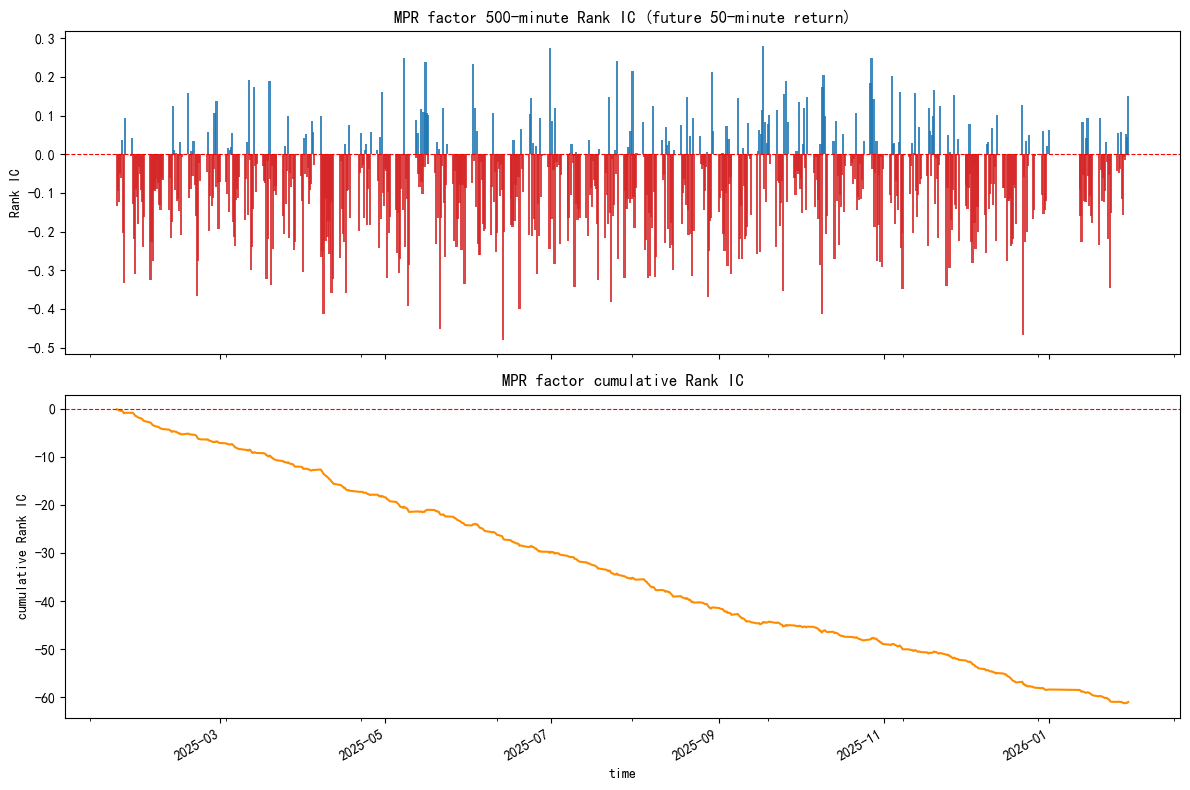

In [25]:
# ──────────────────────────────────────────────────────────────────
# MPR factor's Rank IC and cumulative value
# ──────────────────────────────────────────────────────────────────
ic_mpr_50min = compute_ic_series(xag, 'MPR', 'ret_50m', period)

colors = ['#d62728' if v < 0 else '#1f77b4' for v in ic_mpr_50min['RankIC']]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].bar(ic_mpr_50min.index, ic_mpr_50min['RankIC'], width=0.8, color=colors, alpha=0.85)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].set_title(f'MPR factor {period}-minute Rank IC (future 50-minute return)')
axes[0].set_ylabel('Rank IC')

ic_mpr_50min['RankIC'].cumsum().plot(ax=axes[1], color='darkorange')
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('MPR factor cumulative Rank IC')
axes[1].set_ylabel('cumulative Rank IC')
axes[1].set_xlabel('time')

plt.tight_layout()
plt.show()

## 1.4 Model Fitting

### 1.4.1 Classification models

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, matthews_corrcoef, balanced_accuracy_score
)

# employ rolling window for training and validation
training_size = 500  # training window size
validation_size = 100  # validation window size
step_size = 500  # step size for rolling window

def clean_X_train_val(X_train_df, X_val_df):
    # 1) inf -> nan
    X_train = X_train_df.replace([np.inf, -np.inf], np.nan).copy()
    X_val = X_val_df.replace([np.inf, -np.inf], np.nan).copy()

    # 2) use training set's 1% and 99% quantiles to clip extreme values in both training and validation sets
    q_low = X_train.quantile(0.01)
    q_high = X_train.quantile(0.99)
    X_train = X_train.clip(lower=q_low, upper=q_high, axis=1)
    X_val = X_val.clip(lower=q_low, upper=q_high, axis=1)

    # 3) use training set's median to fill missing values in both training and validation sets
    med = X_train.median()
    X_train = X_train.fillna(med)
    X_val = X_val.fillna(med)

    # 4) after clipping and filling, if there are still inf values (e.g. when quantiles are inf), replace them with 0
    X_train = X_train.replace([np.inf, -np.inf], 0.0)
    X_val = X_val.replace([np.inf, -np.inf], 0.0)

    return X_train.values, X_val.values

def rolling_backtest(df, factor_cols, target_col, model, P, training_size, validation_size, step_size):
    """Rolling window backtest for logistic regression model"""
    classification_metrics = []
    
    for start in range(0, len(df) - training_size - validation_size, step_size):
        train_df = df.iloc[start:start+training_size]
        val_df = df.iloc[start+training_size:start+training_size+validation_size]
        
        X_train_df = train_df[factor_cols]
        X_val_df = val_df[factor_cols]
        y_train = train_df[target_col].values
        y_val = val_df[target_col].values

        # Step 1: data cleaning for features
        X_train, X_val = clean_X_train_val(X_train_df, X_val_df)

        # Step 2: standardize features using training set's parameters
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Step 3(Optional): dimensionality reduction with PCA (fit on training set only)
        if P:
            pca = PCA(n_components=0.8, svd_solver='full')  # retain 80% of the variance
            X_train = pca.fit_transform(X_train)
            X_val = pca.transform(X_val)

        model.fit(X_train, y_train)
        pred_proba = model.predict_proba(X_val)[:, 1]  # predicted probabilities for the positive class
        pred = model.predict(X_val)  # predicted class labels
        
        classification_metrics.append({
            'time': val_df.index[0],
            'accuracy': accuracy_score(y_val, pred),
            'precision': precision_score(y_val, pred),
            'recall': recall_score(y_val, pred),
            'f1': f1_score(y_val, pred),
            'log_loss': log_loss(y_val, pred_proba, labels=[0, 1]),
            'brier_score': brier_score_loss(y_val, pred_proba),
        })
    
    return pd.DataFrame(classification_metrics).set_index('time')


#### 1.4.1.1 Logistic Regression

In [32]:
# ──────────────────────────────────────────────────────────────────
# Logistic regression backtest using all factors to predict n-minute future trend
# ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
## Create different logistic regression models(plain, lasso, ridge, elasticnet) for comparison
logistic_models={
    'LR_plain': LogisticRegression(max_iter=1000, random_state=42),
    'LR_lasso': LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    'LR_ridge': LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=42),
    'LR_elasticnet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, random_state=42)
}

# Summarize metrics for logistic models on 5-minute future trend
print("=== Logistic Regression metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Logistic Regression metrics summary (trend_5m) ===

LR_plain (without PCA)         | Accuracy=0.5027  Precision=0.5191  Recall=0.5406  F1=0.4978  Log Loss=0.7637  Brier Score=0.2777
LR_plain (with PCA)            | Accuracy=0.5018  Precision=0.5195  Recall=0.5640  F1=0.5052  Log Loss=0.7234  Brier Score=0.2636
LR_lasso (without PCA)         | Accuracy=0.5018  Precision=0.5176  Recall=0.5427  F1=0.4976  Log Loss=0.7565  Brier Score=0.2753
LR_lasso (with PCA)            | Accuracy=0.5021  Precision=0.5197  Recall=0.5662  F1=0.5054  Log Loss=0.7216  Brier Score=0.2628
LR_ridge (without PCA)         | Accuracy=0.5027  Precision=0.5191  Recall=0.5406  F1=0.4978  Log Loss=0.7638  Brier Score=0.2777
LR_ridge (with PCA)            | Accuracy=0.5017  Precision=0.5194  Recall=0.5639  F1=0.5051  Log Loss=0.7234  Brier Score=0.2636
LR_elasticnet (without PCA)    | Accuracy=0.5021  Precision=0.5181  Recall=0.5416  F1=0.4975  Log Loss=0.7600  Brier Score=0.2765
LR_elasticnet (with PCA)       | A

In [33]:
# Summarize metrics for all models on 10-minute future trend
print("=== Logistic Regression metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Logistic Regression metrics summary (trend_10m) ===

LR_plain (without PCA)         | Accuracy=0.5063  Precision=0.5283  Recall=0.5517  F1=0.4994  Log Loss=0.7935  Brier Score=0.2864
LR_plain (with PCA)            | Accuracy=0.5028  Precision=0.5296  Recall=0.5776  F1=0.5076  Log Loss=0.7373  Brier Score=0.2688
LR_lasso (without PCA)         | Accuracy=0.5066  Precision=0.5276  Recall=0.5537  F1=0.4993  Log Loss=0.7862  Brier Score=0.2842
LR_lasso (with PCA)            | Accuracy=0.5032  Precision=0.5299  Recall=0.5795  F1=0.5081  Log Loss=0.7351  Brier Score=0.2680
LR_ridge (without PCA)         | Accuracy=0.5063  Precision=0.5284  Recall=0.5517  F1=0.4994  Log Loss=0.7935  Brier Score=0.2864
LR_ridge (with PCA)            | Accuracy=0.5028  Precision=0.5295  Recall=0.5774  F1=0.5075  Log Loss=0.7373  Brier Score=0.2688
LR_elasticnet (without PCA)    | Accuracy=0.5061  Precision=0.5276  Recall=0.5523  F1=0.4988  Log Loss=0.7896  Brier Score=0.2852
LR_elasticnet (with PCA)       | 

In [34]:
# Summarize metrics for all models on 20-minute future trend
print("=== Logistic Regression metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Logistic Regression metrics summary (trend_20m) ===

LR_plain (without PCA)         | Accuracy=0.5033  Precision=0.5318  Recall=0.5564  F1=0.4897  Log Loss=0.8437  Brier Score=0.2996
LR_plain (with PCA)            | Accuracy=0.5047  Precision=0.5342  Recall=0.5902  F1=0.5044  Log Loss=0.7626  Brier Score=0.2775
LR_lasso (without PCA)         | Accuracy=0.5038  Precision=0.5308  Recall=0.5613  F1=0.4910  Log Loss=0.8360  Brier Score=0.2976
LR_lasso (with PCA)            | Accuracy=0.5043  Precision=0.5338  Recall=0.5913  F1=0.5038  Log Loss=0.7598  Brier Score=0.2766
LR_ridge (without PCA)         | Accuracy=0.5032  Precision=0.5327  Recall=0.5563  F1=0.4896  Log Loss=0.8437  Brier Score=0.2996
LR_ridge (with PCA)            | Accuracy=0.5046  Precision=0.5341  Recall=0.5902  F1=0.5043  Log Loss=0.7626  Brier Score=0.2775
LR_elasticnet (without PCA)    | Accuracy=0.5032  Precision=0.5316  Recall=0.5575  F1=0.4896  Log Loss=0.8394  Brier Score=0.2985
LR_elasticnet (with PCA)       | 

In [35]:
# Summarize metrics for all models on 50-minute future trend
print("=== Logistic Regression metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Logistic Regression metrics summary (trend_50m) ===

LR_plain (without PCA)         | Accuracy=0.5137  Precision=0.5480  Recall=0.5861  F1=0.4873  Log Loss=0.9538  Brier Score=0.3174
LR_plain (with PCA)            | Accuracy=0.4998  Precision=0.5389  Recall=0.6112  F1=0.4898  Log Loss=0.8251  Brier Score=0.2948
LR_lasso (without PCA)         | Accuracy=0.5137  Precision=0.5463  Recall=0.5906  F1=0.4883  Log Loss=0.9507  Brier Score=0.3163
LR_lasso (with PCA)            | Accuracy=0.4993  Precision=0.5387  Recall=0.6112  F1=0.4891  Log Loss=0.8214  Brier Score=0.2939
LR_ridge (without PCA)         | Accuracy=0.5137  Precision=0.5475  Recall=0.5862  F1=0.4873  Log Loss=0.9538  Brier Score=0.3174
LR_ridge (with PCA)            | Accuracy=0.4998  Precision=0.5388  Recall=0.6112  F1=0.4898  Log Loss=0.8251  Brier Score=0.2948
LR_elasticnet (without PCA)    | Accuracy=0.5138  Precision=0.5472  Recall=0.5876  F1=0.4872  Log Loss=0.9512  Brier Score=0.3168
LR_elasticnet (with PCA)       | 

#### 1.4.1.1 Generative Models

In [37]:
# test generative classifiers (Naive Bayes, LDA, QDA, KNN) on future trend prediction
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

generative_models = {
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),  # add small regularization to avoid singular covariance
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Summarize metrics for generative models on 5-minute future trend
print("=== Generative model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Generative model metrics summary (trend_5m) ===

Naive Bayes (without PCA)      | Accuracy=0.4972  Precision=0.5184  Recall=0.5056  F1=0.4691  Log Loss=1.0761  Brier Score=0.3277
Naive Bayes (with PCA)         | Accuracy=0.4998  Precision=0.5187  Recall=0.5352  F1=0.4941  Log Loss=0.7667  Brier Score=0.2763
LDA (without PCA)              | Accuracy=0.5075  Precision=0.5401  Recall=0.5304  F1=0.4786  Log Loss=0.8222  Brier Score=0.2920
LDA (with PCA)                 | Accuracy=0.5018  Precision=0.5188  Recall=0.5644  F1=0.5053  Log Loss=0.7230  Brier Score=0.2634
QDA (without PCA)              | Accuracy=0.5004  Precision=0.5185  Recall=0.5264  F1=0.4976  Log Loss=1.1999  Brier Score=0.3432
QDA (with PCA)                 | Accuracy=0.5001  Precision=0.5185  Recall=0.5281  F1=0.4971  Log Loss=0.8803  Brier Score=0.2990
KNN (without PCA)              | Accuracy=0.4992  Precision=0.5131  Recall=0.5276  F1=0.5074  Log Loss=2.5834  Brier Score=0.3129
KNN (with PCA)                 | Accu

In [38]:
# Summarize metrics for generative models on 10-minute future trend
print("=== Generative model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Generative model metrics summary (trend_10m) ===

Naive Bayes (without PCA)      | Accuracy=0.5003  Precision=0.5306  Recall=0.5260  F1=0.4791  Log Loss=1.2246  Brier Score=0.3412
Naive Bayes (with PCA)         | Accuracy=0.5046  Precision=0.5323  Recall=0.5579  F1=0.5049  Log Loss=0.7943  Brier Score=0.2833
LDA (without PCA)              | Accuracy=0.5064  Precision=0.5653  Recall=0.5388  F1=0.4745  Log Loss=0.9006  Brier Score=0.3091
LDA (with PCA)                 | Accuracy=0.5037  Precision=0.5284  Recall=0.5793  F1=0.5085  Log Loss=0.7363  Brier Score=0.2685
QDA (without PCA)              | Accuracy=0.5036  Precision=0.5290  Recall=0.5376  F1=0.4974  Log Loss=1.3615  Brier Score=0.3553
QDA (with PCA)                 | Accuracy=0.5013  Precision=0.5279  Recall=0.5475  F1=0.5037  Log Loss=0.9445  Brier Score=0.3097
KNN (without PCA)              | Accuracy=0.5003  Precision=0.5209  Recall=0.5409  F1=0.5108  Log Loss=3.0818  Brier Score=0.3195
KNN (with PCA)                 | Acc

In [39]:
# Summarize metrics for all models on 20-minute future trend
print("=== Generative model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Generative model metrics summary (trend_20m) ===

Naive Bayes (without PCA)      | Accuracy=0.5028  Precision=0.5330  Recall=0.5366  F1=0.4741  Log Loss=1.4496  Brier Score=0.3594
Naive Bayes (with PCA)         | Accuracy=0.5090  Precision=0.5408  Recall=0.5678  F1=0.4999  Log Loss=0.8314  Brier Score=0.2919
LDA (without PCA)              | Accuracy=0.5057  Precision=0.5688  Recall=0.5475  F1=0.4712  Log Loss=1.0137  Brier Score=0.3276
LDA (with PCA)                 | Accuracy=0.5041  Precision=0.5326  Recall=0.5897  F1=0.5035  Log Loss=0.7610  Brier Score=0.2771
QDA (without PCA)              | Accuracy=0.5031  Precision=0.5387  Recall=0.5444  F1=0.4897  Log Loss=1.5722  Brier Score=0.3695
QDA (with PCA)                 | Accuracy=0.5063  Precision=0.5398  Recall=0.5548  F1=0.4987  Log Loss=1.0390  Brier Score=0.3198
KNN (without PCA)              | Accuracy=0.5063  Precision=0.5345  Recall=0.5608  F1=0.5138  Log Loss=3.5908  Brier Score=0.3239
KNN (with PCA)                 | Acc

In [40]:
# Summarize metrics for all models on 50-minute future trend
print("=== Alternative model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, i, training_size, validation_size, step_size)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        brier_mean = df_metric['brier_score'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Alternative model metrics summary (trend_50m) ===

Naive Bayes (without PCA)      | Accuracy=0.4952  Precision=0.5353  Recall=0.5336  F1=0.4522  Log Loss=1.8399  Brier Score=0.3855
Naive Bayes (with PCA)         | Accuracy=0.4916  Precision=0.5368  Recall=0.5735  F1=0.4736  Log Loss=0.9199  Brier Score=0.3137
LDA (without PCA)              | Accuracy=0.5222  Precision=0.5928  Recall=0.5879  F1=0.4865  Log Loss=1.1894  Brier Score=0.3405
LDA (with PCA)                 | Accuracy=0.4989  Precision=0.5377  Recall=0.6143  F1=0.4894  Log Loss=0.8196  Brier Score=0.2938
QDA (without PCA)              | Accuracy=0.5060  Precision=0.5510  Recall=0.5593  F1=0.4786  Log Loss=1.9382  Brier Score=0.3856
QDA (with PCA)                 | Accuracy=0.4954  Precision=0.5392  Recall=0.5614  F1=0.4757  Log Loss=1.2213  Brier Score=0.3423
KNN (without PCA)              | Accuracy=0.5050  Precision=0.5456  Recall=0.5721  F1=0.4935  Log Loss=4.5111  Brier Score=0.3366
KNN (with PCA)                 | Ac

#### 1.4.1.3 Tree-based models

In [43]:
# test tree-based classifiers (Bagging, Random Forest, Gradient Boosting, XGBoost) on future trend prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

tree_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42),
        n_estimators=200,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        gamma=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}
# Summarize metrics for tree-based models on 5-minute future trend
print("=== Tree-based model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, 0, training_size, validation_size, step_size)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Tree-based model metrics summary (trend_5m) ===

Bagging              | Accuracy=0.5031  Precision=0.5212  Recall=0.5525  F1=0.5007  Log Loss=0.7229  Brier Score=0.2636
Random Forest        | Accuracy=0.5028  Precision=0.5238  Recall=0.5182  F1=0.4923  Log Loss=0.7123  Brier Score=0.2590
Gradient Boosting    | Accuracy=0.5035  Precision=0.5225  Recall=0.5379  F1=0.5037  Log Loss=0.7888  Brier Score=0.2876
XGBoost              | Accuracy=0.5019  Precision=0.5227  Recall=0.5314  F1=0.5028  Log Loss=0.8139  Brier Score=0.2956


In [44]:
# Summarize metrics for tree-based models on 10-minute future trend
print("=== Tree-based model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, 0, training_size, validation_size, step_size)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Tree-based model metrics summary (trend_10m) ===

Bagging              | Accuracy=0.5080  Precision=0.5328  Recall=0.5727  F1=0.5078  Log Loss=0.7365  Brier Score=0.2689
Random Forest        | Accuracy=0.5065  Precision=0.5310  Recall=0.5329  F1=0.4969  Log Loss=0.7188  Brier Score=0.2617
Gradient Boosting    | Accuracy=0.5063  Precision=0.5323  Recall=0.5532  F1=0.5075  Log Loss=0.8100  Brier Score=0.2934
XGBoost              | Accuracy=0.5065  Precision=0.5321  Recall=0.5505  F1=0.5088  Log Loss=0.8412  Brier Score=0.3023


In [45]:
# Summarize metrics for tree-based models on 20-minute future trend
print("=== Tree-based model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, 0, training_size, validation_size, step_size)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Tree-based model metrics summary (trend_20m) ===

Bagging              | Accuracy=0.5081  Precision=0.5422  Recall=0.5736  F1=0.4991  Log Loss=0.7622  Brier Score=0.2784
Random Forest        | Accuracy=0.5090  Precision=0.5470  Recall=0.5439  F1=0.4941  Log Loss=0.7299  Brier Score=0.2663
Gradient Boosting    | Accuracy=0.5109  Precision=0.5460  Recall=0.5646  F1=0.5033  Log Loss=0.8557  Brier Score=0.3061
XGBoost              | Accuracy=0.5112  Precision=0.5476  Recall=0.5648  F1=0.5077  Log Loss=0.8916  Brier Score=0.3145


In [46]:
# Summarize metrics for tree-based models on 50-minute future trend
print("=== Tree-based model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, ALL_FACTORS, TARGET_COL, model, 0, training_size, validation_size, step_size)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}")

=== Tree-based model metrics summary (trend_50m) ===

Bagging              | Accuracy=0.5113  Precision=0.5474  Recall=0.6012  F1=0.4919  Log Loss=0.8124  Brier Score=0.2923
Random Forest        | Accuracy=0.5118  Precision=0.5468  Recall=0.5622  F1=0.4826  Log Loss=0.7490  Brier Score=0.2727
Gradient Boosting    | Accuracy=0.5165  Precision=0.5556  Recall=0.5869  F1=0.4952  Log Loss=0.9316  Brier Score=0.3213
XGBoost              | Accuracy=0.5149  Precision=0.5536  Recall=0.5855  F1=0.4950  Log Loss=0.9640  Brier Score=0.3275
